In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

def find_train_csv():
    for root, dirs, files in os.walk('/content/drive/MyDrive/'):
        if 'train.csv' in files:
            return os.path.join(root, 'train.csv')
    return None

CSV_PATH = find_train_csv()
DATA_DIR = os.path.dirname(CSV_PATH)
BASE_DIR = os.path.dirname(os.path.dirname(DATA_DIR))
PROCESSED_DIR = os.path.join(BASE_DIR, 'data/processed')
RESULTS_DIR = os.path.join(BASE_DIR, 'results_tuan4')
IMAGE_DIR = os.path.join(DATA_DIR, 'train_images')

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

def find_train_csv():
    for root, dirs, files in os.walk('/content/drive/MyDrive/'):
        if 'train.csv' in files:
            return os.path.join(root, 'train.csv')
    return None

CSV_PATH = find_train_csv()
DATA_DIR = os.path.dirname(CSV_PATH)
BASE_DIR = os.path.dirname(os.path.dirname(DATA_DIR))
PROCESSED_DIR = os.path.join(BASE_DIR, 'data/processed')
RESULTS_DIR = os.path.join(BASE_DIR, 'results_tuan4')
IMAGE_DIR = os.path.join(DATA_DIR, 'train_images')

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def evaluate_metrics(predictions, ground_truth):
    k_list = [1, 3, 5]
    max_k = max(k_list)
    query_metrics = []
    all_ap = []
    
    for qid, preds in predictions.items():
        gt = ground_truth.get(qid, set())
        total_relevant = len(gt)
        if total_relevant == 0:
            continue
            
        preds_max_k = preds[:max_k]
        hits = 0
        ap = 0.0
        for rank, p in enumerate(preds_max_k, 1):
            if p in gt:
                hits += 1
                ap += hits / rank
        if total_relevant > 0:
            ap /= total_relevant
        all_ap.append(ap)
        
        row = {}
        for k in k_list:
            preds_k = preds[:k]
            hits_k = sum(1 for p in preds_k if p in gt)
            row[f'Precision@{k}'] = hits_k / k
            denom = min(total_relevant, k) if total_relevant > 0 else 1
            row[f'Recall@{k}'] = hits_k / denom
        query_metrics.append(row)
        
    detail_df = pd.DataFrame(query_metrics)
    mAP = float(np.mean(all_ap))
    
    summary = []
    for k in k_list:
        summary.append({
            'K': k,
            'Precision@K': round(detail_df[f'Precision@{k}'].mean(), 4),
            'Recall@K': round(detail_df[f'Recall@{k}'].mean(), 4)
        })
        
    summary_df = pd.DataFrame(summary)
    print(summary_df.to_string(index=False))
    print(f"\nmAP = {mAP:.4f}\n")
    return summary_df, mAP

gt_dict = {}
group_to_pids = candidate_df.groupby('label_group')['posting_id'].apply(set).to_dict()
for pid, group in zip(candidate_df['posting_id'], candidate_df['label_group']):
    gt_dict[pid] = group_to_pids[group] - {pid}

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', binary=True, max_features=25000)
tfidf_all = vectorizer.fit_transform(candidate_df['title'])
tfidf_test = vectorizer.transform(test_df['title'])

sim_matrix = cosine_similarity(tfidf_test, tfidf_all)

preds_dict = {}
for i in range(len(test_df)):
    qid = posting_ids_test[i]
    sim_row = sim_matrix[i].copy()
    idx_in_all = np.where(posting_ids_all == qid)[0][0]
    sim_row[idx_in_all] = -1.0
    top5_idx = np.argsort(-sim_row)[:5]
    preds_dict[qid] = [posting_ids_all[j] for j in top5_idx]

tfidf_summary, tfidf_map = evaluate_metrics(preds_dict, gt_dict)
tfidf_summary.to_csv(os.path.join(RESULTS_DIR, 'metrics_tfidf_34k.csv'), index=False)

In [ ]:
def popcount_uint64(x):
    x = x - ((x >> np.uint64(1)) & np.uint64(0x5555555555555555))
    x = (x & np.uint64(0x3333333333333333)) + ((x >> np.uint64(2)) & np.uint64(0x3333333333333333))
    x = (x + (x >> np.uint64(4))) & np.uint64(0x0F0F0F0F0F0F0F0F)
    return ((x * np.uint64(0x0101010101010101)) >> np.uint64(56)).astype(np.int32)

phashes_hex_all = candidate_df['image_phash'].astype(str).values
phashes_uint_all = np.array([int(h, 16) for h in phashes_hex_all], dtype=np.uint64)
phashes_hex_test = test_df['image_phash'].astype(str).values
phashes_uint_test = np.array([int(h, 16) for h in phashes_hex_test], dtype=np.uint64)

preds_dict = {}
BATCH = 2000
for i in range(0, len(test_df), BATCH):
    end_i = min(i + BATCH, len(test_df))
    xor = np.bitwise_xor(phashes_uint_test[i:end_i, None], phashes_uint_all[None, :])
    dist_matrix_chunk = popcount_uint64(xor)
    for idx_test in range(i, end_i):
        qid = posting_ids_test[idx_test]
        dist_row = dist_matrix_chunk[idx_test - i].copy()
        idx_in_all = np.where(posting_ids_all == qid)[0][0]
        dist_row[idx_in_all] = 999
        top5_idx = np.argsort(dist_row)[:5]
        preds_dict[qid] = [posting_ids_all[j] for j in top5_idx]

phash_summary, phash_map = evaluate_metrics(preds_dict, gt_dict)
phash_summary.to_csv(os.path.join(RESULTS_DIR, 'metrics_phash_34k.csv'), index=False)

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Identity()
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class ShopeeDataset(torch.utils.data.Dataset):
    def __init__(self, df, image_dir, transform):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image']
        try:
            img_path = os.path.join(self.image_dir, img_name)
            img = Image.open(img_path).convert('RGB')
            tensor = self.transform(img)
        except:
            tensor = torch.zeros(3, 224, 224)
        return tensor

def extract_features_loader(df):
    dataset = ShopeeDataset(df, IMAGE_DIR, transform)
    loader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)
    feats = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting Features"):
            batch = batch.to(device)
            feat = model(batch).cpu().numpy()
            feats.append(feat)
    return np.vstack(feats)

features_all = extract_features_loader(candidate_df)
features_test = features_all[test_idx]

feats_all_tensor = torch.tensor(features_all, dtype=torch.float32, device=device)
feats_test_tensor = torch.tensor(features_test, dtype=torch.float32, device=device)

feats_all_tensor = torch.nn.functional.normalize(feats_all_tensor, p=2, dim=1)
feats_test_tensor = torch.nn.functional.normalize(feats_test_tensor, p=2, dim=1)

sim_matrix_tensor = torch.mm(feats_test_tensor, feats_all_tensor.t())

row_indices = torch.arange(len(test_idx), device=device)
col_indices = torch.tensor(test_idx, device=device)
sim_matrix_tensor[row_indices, col_indices] = -1.0

top5_vals, top5_inds = torch.topk(sim_matrix_tensor, k=5, dim=1, largest=True)
top5_inds = top5_inds.cpu().numpy()

preds_dict = {}
for i in range(len(test_df)):
    qid = posting_ids_test[i]
    preds_dict[qid] = [posting_ids_all[j] for j in top5_inds[i]]

resnet_summary, resnet_map = evaluate_metrics(preds_dict, gt_dict)
resnet_summary.to_csv(os.path.join(RESULTS_DIR, 'metrics_resnet50_34k.csv'), index=False)

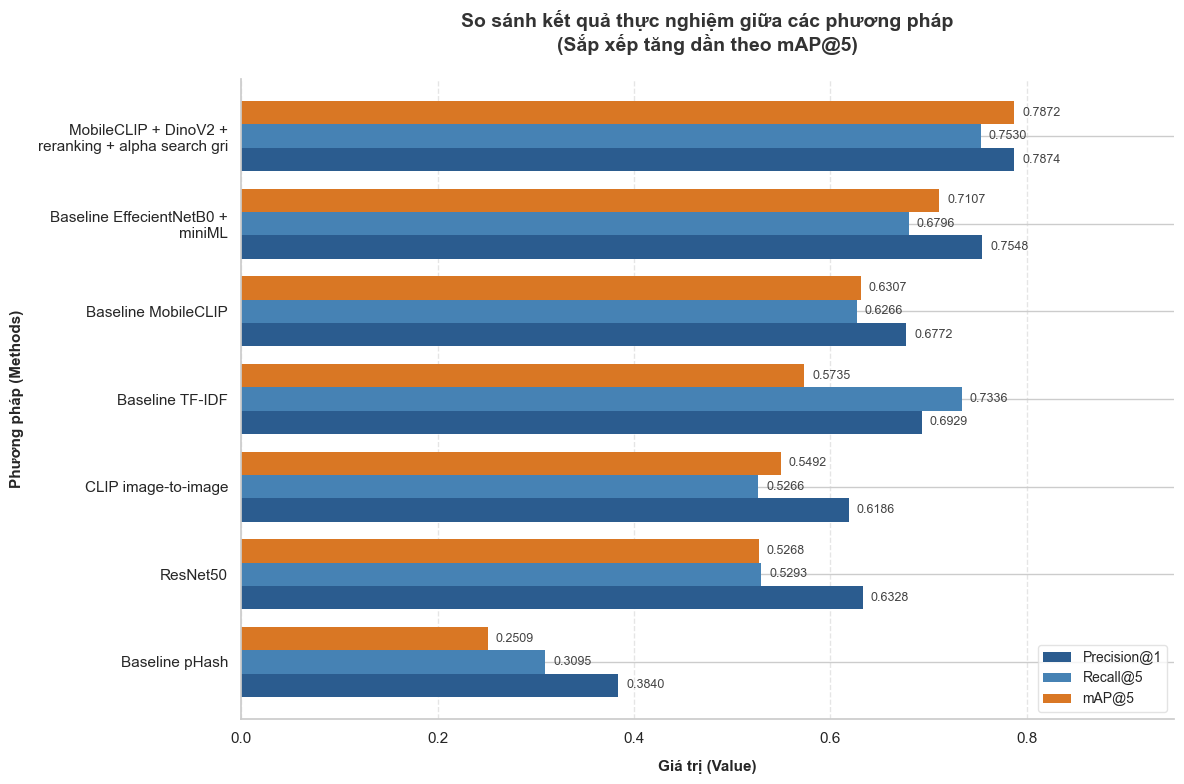

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Chuẩn bị dữ liệu chính xác từ ảnh của bạn
methods = [
    "ResNet50",
    "Baseline pHash",
    "Baseline TF-IDF",
    "CLIP image-to-image",
    "MobileCLIP + DinoV2 +\nreranking + alpha search gri",
    "Baseline EffecientNetB0 +\nminiML",
    "Baseline MobileCLIP",
]

data = {
    "Precision@1": [0.6328, 0.3840, 0.6929, 0.6186, 0.7874, 0.7548, 0.6772],
    "Recall@5": [0.5293, 0.3095, 0.7336, 0.5266, 0.7530, 0.6796, 0.6266],
    "mAP@5": [0.5268, 0.2509, 0.5735, 0.5492, 0.7872, 0.7107, 0.6307],
}

# Chuyển dữ liệu sang DataFrame và sắp xếp tăng dần theo mAP@5
df = pd.DataFrame(data, index=methods)
df_sorted = df.sort_values(by="mAP@5", ascending=True)

# 2. Thiết lập kích thước khung vẽ (bản ngang rộng rãi)
fig, ax = plt.subplots(figsize=(12, 8))

# Sử dụng bảng màu nhã nhặn, chuyên nghiệp cho báo cáo (Xanh đậm, Xanh nhạt, Cam đất)
colors = ["#2b5c8f", "#4682b4", "#d97724"]
df_sorted.plot(kind="barh", ax=ax, width=0.8, color=colors, edgecolor="none")

# 3. Định dạng Tiêu đề và Tên trục
ax.set_title(
    "So sánh kết quả thực nghiệm giữa các phương pháp\n(Sắp xếp tăng dần theo mAP@5)",
    fontsize=14,
    fontweight="bold",
    pad=20,
    color="#333333",
)
ax.set_xlabel("Giá trị (Value)", fontsize=11, fontweight="bold", labelpad=10)
ax.set_ylabel(
    "Phương pháp (Methods)", fontsize=11, fontweight="bold", labelpad=10
)

# Nới rộng trục X một chút để chừa khoảng trống hiển thị số hiệu ở cuối cột
ax.set_xlim(0, 0.95)

# Thêm lưới dọc (grid) nét đứt để dễ dóng hàng bằng mắt
ax.grid(axis="x", linestyle="--", alpha=0.5, color="#cccccc")
ax.set_axisbelow(True)  # Đẩy lưới ẩn ra sau các cột

# Bỏ đường viền khung biểu đồ ở phía trên và bên phải cho thoáng mắt
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# 4. Tự động hiển thị chính xác giá trị số (4 chữ số thập phân) sau mỗi thanh cột
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.4f}",
            xy=(width, p.get_y() + p.get_height() / 2),
            xytext=(6, 0),  # Đẩy chữ lùi ra sau thanh cột 6 pixel
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9,
            color="#444444",
            fontweight="medium",
        )

# 5. Cài đặt hộp chú thích (Legend) ở góc dưới bên phải
ax.legend(
    loc="lower right",
    frameon=True,
    facecolor="#ffffff",
    edgecolor="#dddddd",
    fontsize=10,
)

# Tối ưu hóa khoảng cách để không bị mất chữ phương pháp ở lề trái
plt.tight_layout()

# 6. Hiển thị biểu đồ ra màn hình
plt.show()